Comparison of:
 - autoencoder_baseline.keras (Baseline Autoencoder)
 - autoencoder_ameliore.keras (Improved Autoencoder)
 - autoencoder_maml.keras (Meta-Learning Autoencoder)
 - vae_normal.keras (VAE Density Model)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.models import load_model

Step 1: Load Preprocessed Embeddings

In [ ]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


case epoch= 1 ( less then 15, gave approximately same result so we took case 1 epoch=1 )

Normal embeddings range: 0.0 1.0
Attack embeddings range: 0.0 21888.004

Loading Baseline Autoencoder from /content/drive/MyDrive/zeroday_detection/models/autoencoder_baseline_m3_d64_v2.keras
12187/12187 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step
50444/50444 ━━━━━━━━━━━━━━━━━━━━ 63s 1ms/step


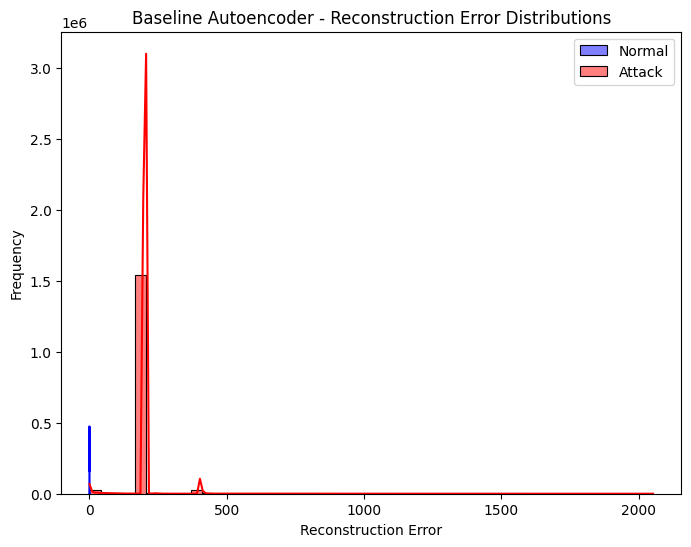


Loading Autoencoder from /content/drive/MyDrive/zeroday_detection/models/autoencoder_model_v2.keras
12187/12187 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step
50444/50444 ━━━━━━━━━━━━━━━━━━━━ 61s 1ms/step


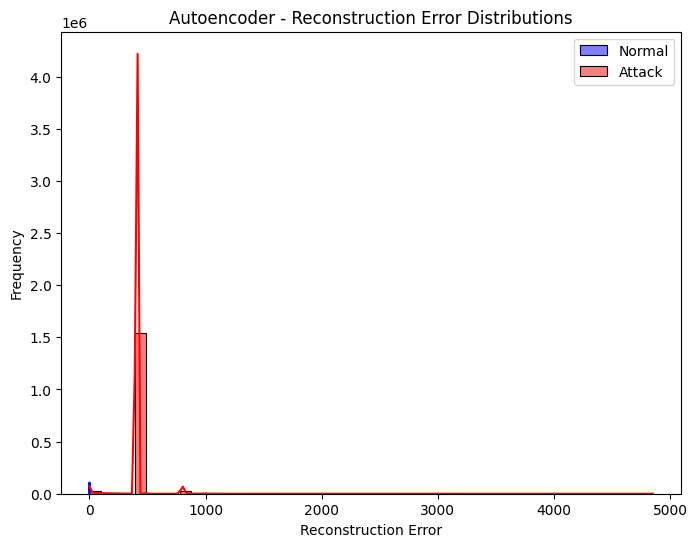


Loading Improved Autoencoder (Ameliore) from /content/drive/MyDrive/zeroday_detection/models/autoencoder_ameliore_v2.keras
12187/12187 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step
50444/50444 ━━━━━━━━━━━━━━━━━━━━ 65s 1ms/step


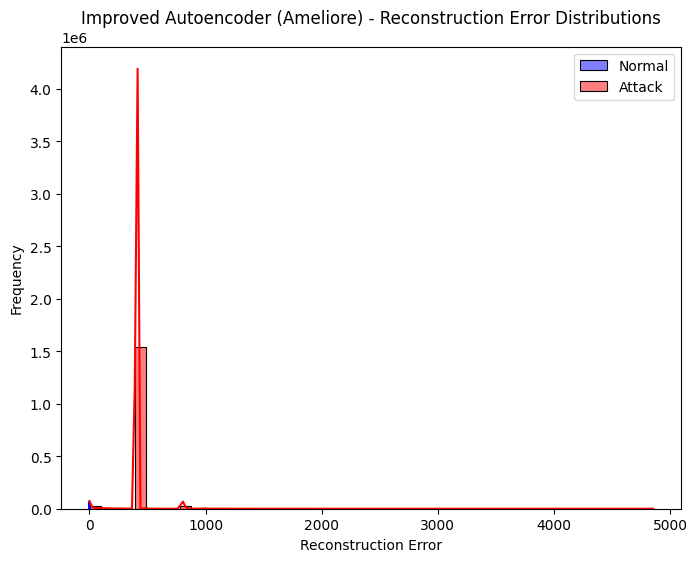


Loading MAML Autoencoder from /content/drive/MyDrive/zeroday_detection/models/maml_meta_model_v2.h5
12187/12187 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step
50444/50444 ━━━━━━━━━━━━━━━━━━━━ 58s 1ms/step


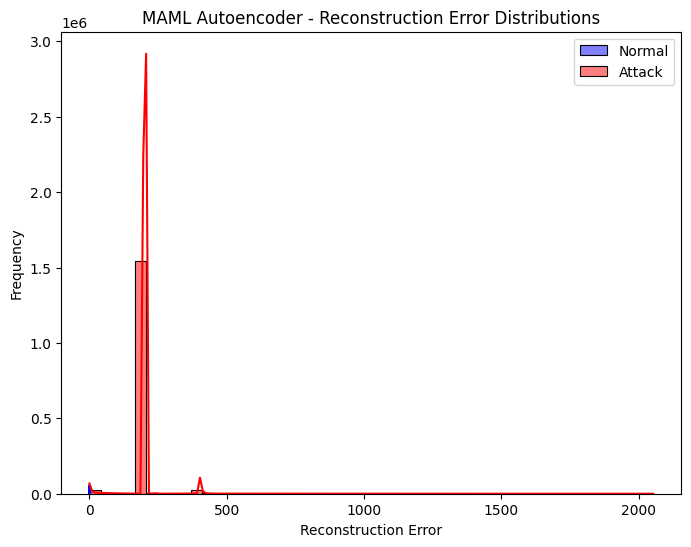


Loading VAE Density Model from /content/drive/MyDrive/zeroday_detection/models/vae_normal_v2.keras
Error loading VAE model: A total of 4 objects could not be loaded. Example error message for object <Dense name=dense_11, built=True>:

Layer 'dense_11' expected 2 variables, but received 0 variables during loading. Expected: ['kernel', 'bias']

List of objects that could not be loaded:
[<Dense name=dense_11, built=True>, <Dense name=dense_12, built=True>, <Dense name=dense_7, built=True>, <Dense name=dense_8, built=True>]

=== Evaluation for Baseline Autoencoder ===
Chosen threshold (95th percentile): 0.01083
Confusion Matrix:
 [[ 370458   19498]
 [      0 1614182]]
Classification Report:
               precision    recall  f1-score   support

      Normal       1.00      0.95      0.97    389956
      Attack       0.99      1.00      0.99   1614182

    accuracy                           0.99   2004138
   macro avg       0.99      0.97      0.98   2004138
weighted avg       0.99      0

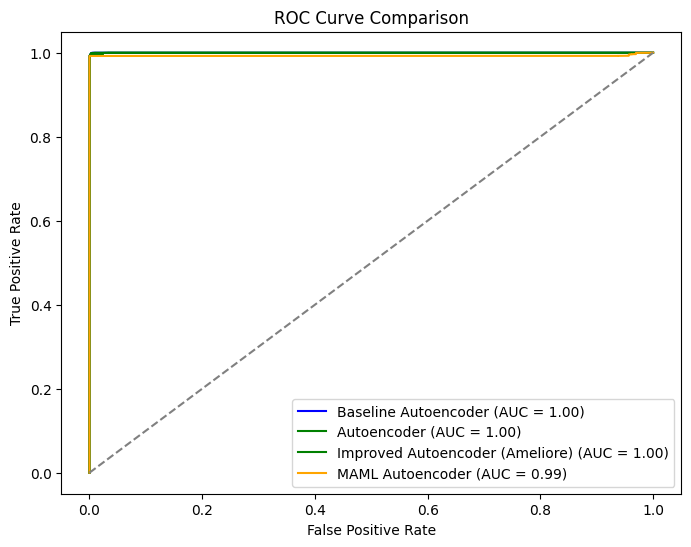

Summary of Evaluation Results:
                             Model  Threshold   ROC AUC  \
0             Baseline Autoencoder   0.010833  0.999985   
1                      Autoencoder   0.214682  0.999977   
2  Improved Autoencoder (Ameliore)   0.283738  0.999895   
3                 MAML Autoencoder   0.487219  0.992596   

                      Confusion Matrix  \
0      [[370458, 19498], [0, 1614182]]   
1     [[370460, 19496], [35, 1614147]]   
2      [[370458, 19498], [9, 1614173]]   
3  [[370797, 19159], [12473, 1601709]]   

                               Classification Report  
0                precision    recall  f1-score   ...  
1                precision    recall  f1-score   ...  
2                precision    recall  f1-score   ...  
3                precision    recall  f1-score   ...  


In [ ]:
# ================================
# Module 5: Evaluation and Reporting - Comparison of Models
# Models compared:
#   - Baseline Autoencoder (trained on 64-dim embeddings)
#   - Improved Autoencoder (trained on 39-dim inputs)
#   - Improved Autoencoder (Ameliore version, trained on 39-dim inputs)
#   - MAML Autoencoder (trained on 64-dim inputs)
#   - VAE Density Model (trained on scaled embeddings, 64-dim)
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load the embeddings from Module 2 (assumed to be from SimCLR)
embeddings_normal = np.load("/content/drive/MyDrive/zeroday_detection/data/embeddings_normal_v2.npy")
embeddings_attack = np.load("/content/drive/MyDrive/zeroday_detection/data/embeddings_attack_v2.npy")

# ----- Step 2: Rescale Embeddings to [0,1] -----
scaler = MinMaxScaler()
embeddings_normal_scaled = scaler.fit_transform(embeddings_normal)
embeddings_attack_scaled = scaler.transform(embeddings_attack)

print("Normal embeddings range:", np.min(embeddings_normal_scaled), np.max(embeddings_normal_scaled))
print("Attack embeddings range:", np.min(embeddings_attack_scaled), np.max(embeddings_attack_scaled))

# ----- Step 3: Define a Function to Compute Reconstruction Errors -----
def compute_reconstruction_error(model, data):
    reconstructions = model.predict(data)
    errors = np.mean(np.abs(reconstructions - data), axis=1)
    # Remove any NaN error values.
    errors = errors[~np.isnan(errors)]
    return errors

# ----- Step 4: Define a Custom VAE Class with Proper Serialization -----
# This will allow Keras to load the VAE model properly.
from tensorflow.keras import layers, Model
from tensorflow.keras.initializers import GlorotUniform

@tf.keras.utils.register_keras_serializable()
class VAE(Model):
    def __init__(self, encoder, decoder, input_dim, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.input_dim = input_dim

    def call(self, inputs):
        # Encode the inputs to obtain mean and log variance.
        z_mean, z_log_var = self.encoder(inputs)
        epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], tf.shape(z_mean)[1]))
        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon
        reconstruction = self.decoder(z)
        # Compute reconstruction loss.
        reconstruction_loss = tf.reduce_mean(tf.keras.losses.mse(inputs, reconstruction)) * self.input_dim
        # Compute KL divergence loss.
        epsilon_const = 1e-8
        kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        kl_loss = -0.5 * tf.reduce_mean(kl_loss + epsilon_const)
        total_loss = reconstruction_loss + kl_loss
        self.add_loss(total_loss)
        return reconstruction

    def get_config(self):
        config = super(VAE, self).get_config()
        config.update({"input_dim": self.input_dim})
        return config

    @classmethod
    def from_config(cls, config, custom_objects=None):
        # Ensure custom_objects is not None.
        if custom_objects is None:
            custom_objects = {}
        # Use provided custom builders or fall back to local functions.
        encoder_fn = custom_objects.get("encoder_builder", encoder_builder)
        decoder_fn = custom_objects.get("decoder_builder", decoder_builder)
        # Use a default input dimension of 64 if not provided in config.
        input_dim = config.get("input_dim", 64)
        encoder = encoder_fn()
        decoder = decoder_fn(input_dim)
        return cls(encoder, decoder, input_dim, **config)

# Define builder functions for the encoder and decoder (for VAE)
def encoder_builder():
    latent_dim = 16
    input_dim = 64  # Adjust based on actual input shape if needed.
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu', kernel_initializer=GlorotUniform())(inputs)
    x = layers.Dense(32, activation='relu', kernel_initializer=GlorotUniform())(x)
    z_mean = layers.Dense(latent_dim, kernel_initializer=GlorotUniform())(x)
    z_log_var = layers.Dense(latent_dim, kernel_initializer=GlorotUniform())(x)
    return Model(inputs, [z_mean, z_log_var], name="encoder")

def decoder_builder(input_dim):
    latent_dim = 16
    latent_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(32, activation='relu', kernel_initializer=GlorotUniform())(latent_inputs)
    x = layers.Dense(64, activation='relu', kernel_initializer=GlorotUniform())(x)
    outputs = layers.Dense(input_dim, activation='sigmoid')(x)
    return Model(latent_inputs, outputs, name="decoder")

# ----- Step 5: Define Model Paths & Adjust Input Dimensions -----
model_info = {
    "Baseline Autoencoder": "/content/drive/MyDrive/zeroday_detection/models/autoencoder_baseline_m3_d64_v2.keras",
    "Autoencoder": "/content/drive/MyDrive/zeroday_detection/models/autoencoder_model_v2.keras",
    "Improved Autoencoder (Ameliore)": "/content/drive/MyDrive/zeroday_detection/models/autoencoder_ameliore_v2.keras",
    "MAML Autoencoder": "/content/drive/MyDrive/zeroday_detection/models/maml_meta_model_v2.h5",
    "VAE Density Model": "/content/drive/MyDrive/zeroday_detection/models/vae_normal_v2.keras"
}

results = {}
# For models expecting 39-dimensional inputs (the Improved autoencoders), apply PCA to reduce the dimension from 64 to 39.
pca_39 = PCA(n_components=39)
embeddings_normal_39 = pca_39.fit_transform(embeddings_normal_scaled)
embeddings_attack_39 = pca_39.transform(embeddings_attack_scaled)

# Loop through each model and load with proper input dimensions.
for model_name, model_path in model_info.items():
    print(f"\nLoading {model_name} from {model_path}")

    if model_name == "VAE Density Model":
        # VAE Density Model uses custom VAE deserialization.
        custom_objects = {
            "VAE": VAE,
            "encoder_builder": encoder_builder,
            "decoder_builder": decoder_builder
        }
        try:
            model = load_model(model_path, compile=False, custom_objects=custom_objects)
        except Exception as e:
            print(f"Error loading VAE model: {e}")
            continue
        # VAE is trained on 64-dim embeddings.
        input_data_normal = embeddings_normal_scaled
        input_data_attack = embeddings_attack_scaled
    elif model_name in ["Baseline Autoencoder", "MAML Autoencoder"]:
        # Both Baseline and MAML Autoencoders expect 64-dim inputs.
        try:
            model = load_model(model_path, compile=False)
        except Exception as e:
            print(f"Error loading {model_name}: {e}")
            continue
        input_data_normal = embeddings_normal_scaled
        input_data_attack = embeddings_attack_scaled
    elif model_name in ["Autoencoder", "Improved Autoencoder (Ameliore)"]:
        # Improved autoencoders were trained on 39-dim inputs.
        try:
            model = load_model(model_path, compile=False)
        except Exception as e:
            print(f"Error loading {model_name}: {e}")
            continue
        input_data_normal = embeddings_normal_39
        input_data_attack = embeddings_attack_39
    else:
        # Fallback: use 64-dim inputs.
        try:
            model = load_model(model_path, compile=False)
        except Exception as e:
            print(f"Error loading {model_name}: {e}")
            continue
        input_data_normal = embeddings_normal_scaled
        input_data_attack = embeddings_attack_scaled

    try:
        errors_normal = compute_reconstruction_error(model, input_data_normal)
        errors_attack = compute_reconstruction_error(model, input_data_attack)
    except Exception as e:
        print(f"Error computing reconstruction error for {model_name}: {e}")
        continue

    results[model_name] = {
        "errors_normal": errors_normal,
        "errors_attack": errors_attack
    }

    # Plot the reconstruction error distributions.
    plt.figure(figsize=(8,6))
    sns.histplot(errors_normal, bins=50, kde=True, label="Normal", color="blue")
    sns.histplot(errors_attack, bins=50, kde=True, label="Attack", color="red")
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Frequency")
    plt.title(f"{model_name} - Reconstruction Error Distributions")
    plt.legend()
    plt.show()

# ----- Step 6: Evaluate Anomaly Detection for Each Model -----
def evaluate_model(errors_normal, errors_attack, percentile=95):
    # Determine threshold based on the normal error distribution.
    threshold = np.percentile(errors_normal, percentile)
    print(f"Chosen threshold ({percentile}th percentile): {threshold:.5f}")

    # Create ground truth labels: 0 for normal, 1 for attack.
    y_true = np.concatenate([np.zeros(len(errors_normal)), np.ones(len(errors_attack))])
    y_pred = np.concatenate([errors_normal > threshold, errors_attack > threshold]).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    cr = classification_report(y_true, y_pred, target_names=["Normal", "Attack"])

    # Concatenate errors.
    all_errors = np.concatenate([errors_normal, errors_attack])
    # --- NEW: Filter out any NaN (or infinite) values and their corresponding labels ---
    mask = ~np.isnan(all_errors)
    filtered_errors = all_errors[mask]
    filtered_y_true = y_true[mask]

    fpr, tpr, _ = roc_curve(filtered_y_true, filtered_errors)
    roc_auc = auc(fpr, tpr)

    return threshold, cm, cr, fpr, tpr, roc_auc

evaluation_results = {}
for model_name, data in results.items():
    print(f"\n=== Evaluation for {model_name} ===")
    threshold, cm, cr, fpr, tpr, roc_auc = evaluate_model(data["errors_normal"], data["errors_attack"], percentile=95)
    evaluation_results[model_name] = {
        "threshold": threshold,
        "confusion_matrix": cm,
        "classification_report": cr,
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc
    }
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", cr)
    print(f"ROC AUC: {roc_auc:.2f}\n")

# ----- Step 7: Plot ROC Curves for All Models -----
plt.figure(figsize=(8,6))
colors = {
    "Baseline Autoencoder": "blue",
    "Autoencoder": "green",
    "Improved Autoencoder (Ameliore)": "green",
    "MAML Autoencoder": "orange",
    "VAE Density Model": "red"
}
for model_name, eval_data in evaluation_results.items():
    plt.plot(eval_data["fpr"], eval_data["tpr"],
             label=f"{model_name} (AUC = {eval_data['roc_auc']:.2f})",
             color=colors.get(model_name, "black"))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ----- Step 8: Summarize Evaluation Results -----
summary = []
for model_name, eval_data in evaluation_results.items():
    summary.append({
        "Model": model_name,
        "Threshold": eval_data["threshold"],
        "ROC AUC": eval_data["roc_auc"],
        "Confusion Matrix": eval_data["confusion_matrix"],
        "Classification Report": eval_data["classification_report"]
    })
summary_df = pd.DataFrame(summary)
print("Summary of Evaluation Results:")
print(summary_df)


In [ ]:
# ================================
# Module 5: Evaluation and Reporting - Comparison of Models
# Models compared:
#   - Baseline Autoencoder (trained on 64-dim embeddings)
#   - Improved Autoencoder (trained on 39-dim inputs)
#   - Improved Autoencoder (Ameliore version, trained on 39-dim inputs)
#   - MAML Autoencoder (trained on 64-dim inputs)
#   - VAE Density Model (trained on scaled embeddings, 64-dim)
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load the embeddings from Module 2 (assumed to be from SimCLR)
embeddings_normal = np.load("/content/drive/MyDrive/zeroday_detection/data/embeddings_normal_v2.npy")
embeddings_attack = np.load("/content/drive/MyDrive/zeroday_detection/data/embeddings_attack_v2.npy")

# ----- Step 2: Rescale Embeddings to [0,1] -----
scaler = MinMaxScaler()
embeddings_normal_scaled = scaler.fit_transform(embeddings_normal)
embeddings_attack_scaled = scaler.transform(embeddings_attack)

print("Normal embeddings range:", np.min(embeddings_normal_scaled), np.max(embeddings_normal_scaled))
print("Attack embeddings range:", np.min(embeddings_attack_scaled), np.max(embeddings_attack_scaled))

# ----- Step 3: Define a Function to Compute Reconstruction Errors -----
def compute_reconstruction_error(model, data):
    reconstructions = model.predict(data)
    errors = np.mean(np.abs(reconstructions - data), axis=1)
    # Remove any NaN error values.
    errors = errors[~np.isnan(errors)]
    return errors

# ----- Step 4: Define a Custom VAE Class with Proper Serialization -----
# This will allow Keras to load the VAE model properly.
from tensorflow.keras import layers, Model
from tensorflow.keras.initializers import GlorotUniform

@tf.keras.utils.register_keras_serializable()
class VAE(Model):
    def __init__(self, encoder, decoder, input_dim, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.input_dim = input_dim

    def call(self, inputs):
        # Encode the inputs to obtain mean and log variance.
        z_mean, z_log_var = self.encoder(inputs)
        epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], tf.shape(z_mean)[1]))
        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon
        reconstruction = self.decoder(z)
        # Compute reconstruction loss.
        reconstruction_loss = tf.reduce_mean(tf.keras.losses.mse(inputs, reconstruction)) * self.input_dim
        # Compute KL divergence loss.
        epsilon_const = 1e-8
        kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        kl_loss = -0.5 * tf.reduce_mean(kl_loss + epsilon_const)
        total_loss = reconstruction_loss + kl_loss
        self.add_loss(total_loss)
        return reconstruction

    def get_config(self):
        config = super(VAE, self).get_config()
        config.update({"input_dim": self.input_dim})
        return config

    @classmethod
    def from_config(cls, config, custom_objects=None):
        # Ensure custom_objects is not None.
        if custom_objects is None:
            custom_objects = {}
        # Use provided custom builders or fall back to local functions.
        encoder_fn = custom_objects.get("encoder_builder", encoder_builder)
        decoder_fn = custom_objects.get("decoder_builder", decoder_builder)
        # Use a default input dimension of 64 if not provided in config.
        input_dim = config.get("input_dim", 64)
        encoder = encoder_fn()
        decoder = decoder_fn(input_dim)
        return cls(encoder, decoder, input_dim, **config)

# Define builder functions for the encoder and decoder (for VAE)
def encoder_builder():
    latent_dim = 16
    input_dim = 64  # Adjust based on actual input shape if needed.
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu', kernel_initializer=GlorotUniform())(inputs)
    x = layers.Dense(32, activation='relu', kernel_initializer=GlorotUniform())(x)
    z_mean = layers.Dense(latent_dim, kernel_initializer=GlorotUniform())(x)
    z_log_var = layers.Dense(latent_dim, kernel_initializer=GlorotUniform())(x)
    return Model(inputs, [z_mean, z_log_var], name="encoder")

def decoder_builder(input_dim):
    latent_dim = 16
    latent_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(32, activation='relu', kernel_initializer=GlorotUniform())(latent_inputs)
    x = layers.Dense(64, activation='relu', kernel_initializer=GlorotUniform())(x)
    outputs = layers.Dense(input_dim, activation='sigmoid')(x)
    return Model(latent_inputs, outputs, name="decoder")

# ----- Step 5: Define Model Paths & Adjust Input Dimensions -----
model_info = {
    "Baseline Autoencoder": "/content/drive/MyDrive/zeroday_detection/models/autoencoder_baseline_m3_d64_v2.keras",
    "Autoencoder": "/content/drive/MyDrive/zeroday_detection/models/autoencoder_model_v2.keras",
    "Improved Autoencoder (Ameliore)": "/content/drive/MyDrive/zeroday_detection/models/autoencoder_ameliore_v2.keras",
    "MAML Autoencoder": "/content/drive/MyDrive/zeroday_detection/models/maml_meta_model_v2.h5",
    "VAE Density Model": "/content/drive/MyDrive/zeroday_detection/models/vae_normal_v2.keras"
}

results = {}
# For models expecting 39-dimensional inputs (the Improved autoencoders), apply PCA to reduce the dimension from 64 to 39.
pca_39 = PCA(n_components=39)
embeddings_normal_39 = pca_39.fit_transform(embeddings_normal_scaled)
embeddings_attack_39 = pca_39.transform(embeddings_attack_scaled)

# Loop through each model and load with proper input dimensions.
for model_name, model_path in model_info.items():
    print(f"\nLoading {model_name} from {model_path}")

    if model_name == "VAE Density Model":
        # VAE Density Model uses custom VAE deserialization.
        custom_objects = {
            "VAE": VAE,
            "encoder_builder": encoder_builder,
            "decoder_builder": decoder_builder
        }
        try:
            model = load_model(model_path, compile=False, custom_objects=custom_objects)
        except Exception as e:
            print(f"Error loading VAE model: {e}")
            continue
        # VAE is trained on 64-dim embeddings.
        input_data_normal = embeddings_normal_scaled
        input_data_attack = embeddings_attack_scaled
    elif model_name in ["Baseline Autoencoder", "MAML Autoencoder"]:
        # Both Baseline and MAML Autoencoders expect 64-dim inputs.
        try:
            model = load_model(model_path, compile=False)
        except Exception as e:
            print(f"Error loading {model_name}: {e}")
            continue
        input_data_normal = embeddings_normal_scaled
        input_data_attack = embeddings_attack_scaled
    elif model_name in ["Autoencoder", "Improved Autoencoder (Ameliore)"]:
        # Improved autoencoders were trained on 39-dim inputs.
        try:
            model = load_model(model_path, compile=False)
        except Exception as e:
            print(f"Error loading {model_name}: {e}")
            continue
        input_data_normal = embeddings_normal_39
        input_data_attack = embeddings_attack_39
    else:
        # Fallback: use 64-dim inputs.
        try:
            model = load_model(model_path, compile=False)
        except Exception as e:
            print(f"Error loading {model_name}: {e}")
            continue
        input_data_normal = embeddings_normal_scaled
        input_data_attack = embeddings_attack_scaled

    try:
        errors_normal = compute_reconstruction_error(model, input_data_normal)
        errors_attack = compute_reconstruction_error(model, input_data_attack)
    except Exception as e:
        print(f"Error computing reconstruction error for {model_name}: {e}")
        continue

    results[model_name] = {
        "errors_normal": errors_normal,
        "errors_attack": errors_attack
    }

    # Plot the reconstruction error distributions.
    plt.figure(figsize=(8,6))
    sns.histplot(errors_normal, bins=50, kde=True, label="Normal", color="blue")
    sns.histplot(errors_attack, bins=50, kde=True, label="Attack", color="red")
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Frequency")
    plt.title(f"{model_name} - Reconstruction Error Distributions")
    plt.legend()
    plt.show()

# ----- Step 6: Evaluate Anomaly Detection for Each Model -----
def evaluate_model(errors_normal, errors_attack, percentile=95):
    # Determine threshold based on the normal error distribution.
    threshold = np.percentile(errors_normal, percentile)
    print(f"Chosen threshold ({percentile}th percentile): {threshold:.5f}")

    # Create ground truth labels: 0 for normal, 1 for attack.
    y_true = np.concatenate([np.zeros(len(errors_normal)), np.ones(len(errors_attack))])
    y_pred = np.concatenate([errors_normal > threshold, errors_attack > threshold]).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    cr = classification_report(y_true, y_pred, target_names=["Normal", "Attack"])

    # Concatenate errors.
    all_errors = np.concatenate([errors_normal, errors_attack])
    # --- NEW: Filter out any NaN (or infinite) values and their corresponding labels ---
    mask = ~np.isnan(all_errors)
    filtered_errors = all_errors[mask]
    filtered_y_true = y_true[mask]

    fpr, tpr, _ = roc_curve(filtered_y_true, filtered_errors)
    roc_auc = auc(fpr, tpr)

    return threshold, cm, cr, fpr, tpr, roc_auc

evaluation_results = {}
for model_name, data in results.items():
    print(f"\n=== Evaluation for {model_name} ===")
    threshold, cm, cr, fpr, tpr, roc_auc = evaluate_model(data["errors_normal"], data["errors_attack"], percentile=95)
    evaluation_results[model_name] = {
        "threshold": threshold,
        "confusion_matrix": cm,
        "classification_report": cr,
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc
    }
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", cr)
    print(f"ROC AUC: {roc_auc:.2f}\n")

# ----- Step 7: Plot ROC Curves for All Models -----
plt.figure(figsize=(8,6))
colors = {
    "Baseline Autoencoder": "blue",
    "Autoencoder": "green",
    "Improved Autoencoder (Ameliore)": "green",
    "MAML Autoencoder": "orange",
    "VAE Density Model": "red"
}
for model_name, eval_data in evaluation_results.items():
    plt.plot(eval_data["fpr"], eval_data["tpr"],
             label=f"{model_name} (AUC = {eval_data['roc_auc']:.2f})",
             color=colors.get(model_name, "black"))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ----- Step 8: Summarize Evaluation Results -----
summary = []
for model_name, eval_data in evaluation_results.items():
    summary.append({
        "Model": model_name,
        "Threshold": eval_data["threshold"],
        "ROC AUC": eval_data["roc_auc"],
        "Confusion Matrix": eval_data["confusion_matrix"],
        "Classification Report": eval_data["classification_report"]
    })
summary_df = pd.DataFrame(summary)
print("Summary of Evaluation Results:")
print(summary_df)


Sweet home Alabama

now with 50 epoch

Normal embeddings range: 0.0 1.0
Attack embeddings range: 0.0 9999.983

Loading Baseline Autoencoder from /content/drive/MyDrive/zeroday_detection/models/autoencoder_baseline_m3_d64_v2.keras
12187/12187 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step
50444/50444 ━━━━━━━━━━━━━━━━━━━━ 66s 1ms/step


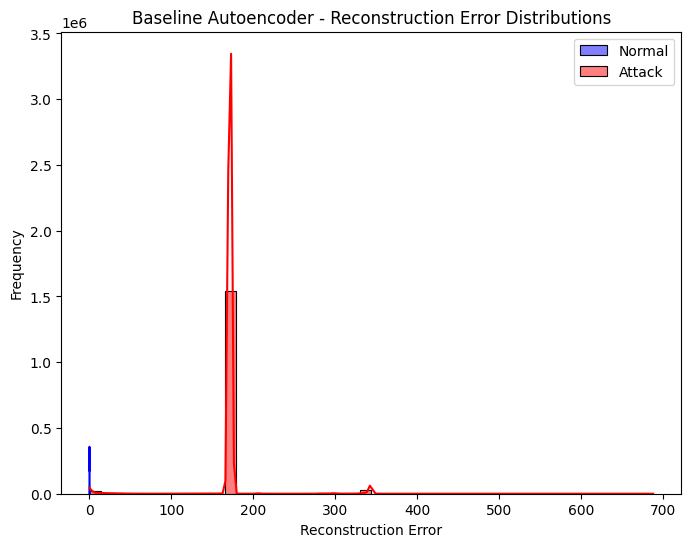


Loading Autoencoder from /content/drive/MyDrive/zeroday_detection/models/autoencoder_model_v2.keras
12187/12187 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step
50444/50444 ━━━━━━━━━━━━━━━━━━━━ 63s 1ms/step


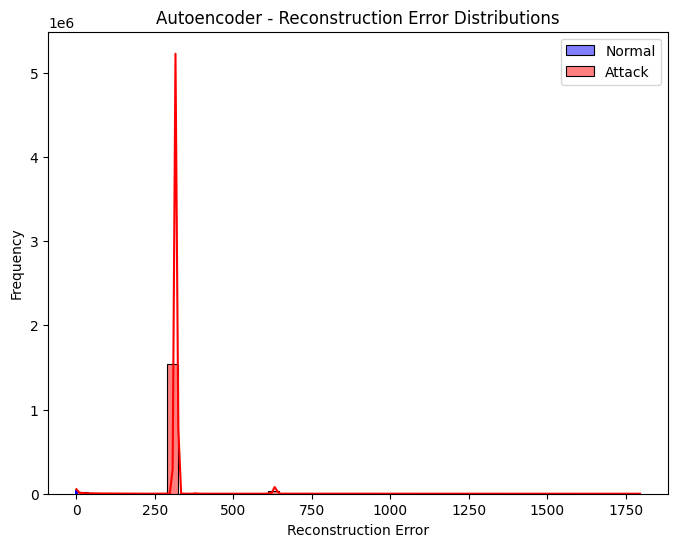


Loading Improved Autoencoder (Ameliore) from /content/drive/MyDrive/zeroday_detection/models/autoencoder_ameliore_v2.keras
12187/12187 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step
50444/50444 ━━━━━━━━━━━━━━━━━━━━ 65s 1ms/step


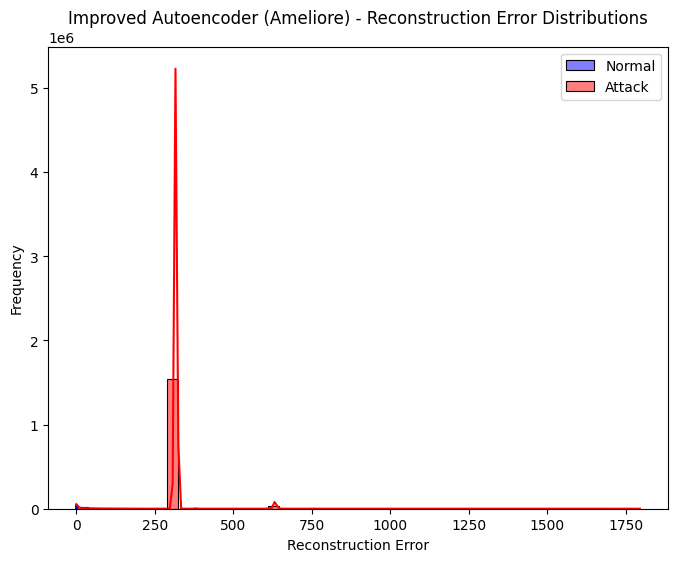


Loading MAML Autoencoder from /content/drive/MyDrive/zeroday_detection/models/maml_meta_model_v2.h5
12187/12187 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step
50444/50444 ━━━━━━━━━━━━━━━━━━━━ 61s 1ms/step


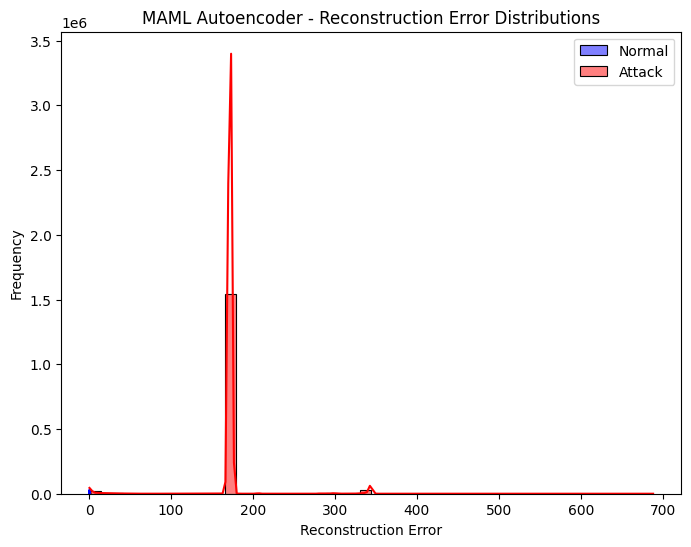


Loading VAE Density Model from /content/drive/MyDrive/zeroday_detection/models/vae_normal_v2.keras
Error loading VAE model: LoadOptions.__init__() got an unexpected keyword argument 'experimental_skip_checkpoint_mismatch'

=== Evaluation for Baseline Autoencoder ===
Chosen threshold (95th percentile): 0.02362
Confusion Matrix:
 [[ 370458   19498]
 [      6 1614176]]
Classification Report:
               precision    recall  f1-score   support

      Normal       1.00      0.95      0.97    389956
      Attack       0.99      1.00      0.99   1614182

    accuracy                           0.99   2004138
   macro avg       0.99      0.97      0.98   2004138
weighted avg       0.99      0.99      0.99   2004138

ROC AUC: 1.00


=== Evaluation for Autoencoder ===
Chosen threshold (95th percentile): 0.24030
Confusion Matrix:
 [[ 370458   19498]
 [   5693 1608489]]
Classification Report:
               precision    recall  f1-score   support

      Normal       0.98      0.95      0.97    

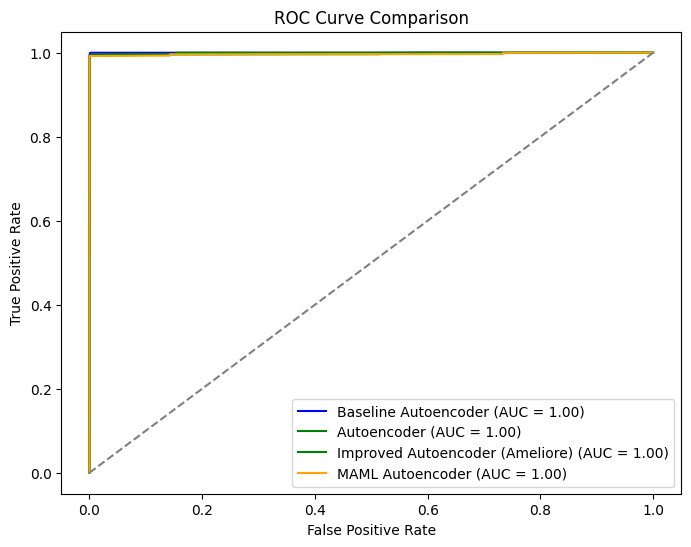

Summary of Evaluation Results:
                             Model  Threshold   ROC AUC  \
0             Baseline Autoencoder   0.023618  0.999995   
1                      Autoencoder   0.240300  0.999442   
2  Improved Autoencoder (Ameliore)   0.294962  0.997856   
3                 MAML Autoencoder   0.479283  0.996906   

                      Confusion Matrix  \
0      [[370458, 19498], [6, 1614176]]   
1   [[370458, 19498], [5693, 1608489]]   
2   [[370458, 19498], [7342, 1606840]]   
3  [[370458, 19498], [12362, 1601820]]   

                               Classification Report  
0                precision    recall  f1-score   ...  
1                precision    recall  f1-score   ...  
2                precision    recall  f1-score   ...  
3                precision    recall  f1-score   ...  


In [ ]:
# ================================
# Module 5: Evaluation and Reporting - Comparison of Models
# Models compared:
#   - Baseline Autoencoder (trained on 64-dim embeddings)
#   - Improved Autoencoder (trained on 39-dim inputs)
#   - Improved Autoencoder (Ameliore version, trained on 39-dim inputs)
#   - MAML Autoencoder (trained on 64-dim inputs)
#   - VAE Density Model (trained on scaled embeddings, 64-dim)
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load embeddings from Module 2 (e.g., from SimCLR)
embeddings_normal = np.load("/content/drive/MyDrive/zeroday_detection/data/embeddings_normal_v2.npy")
embeddings_attack = np.load("/content/drive/MyDrive/zeroday_detection/data/embeddings_attack_v2.npy")

# ----- Step 2: Rescale Embeddings to [0,1] -----
scaler = MinMaxScaler()
embeddings_normal_scaled = scaler.fit_transform(embeddings_normal)
embeddings_attack_scaled = scaler.transform(embeddings_attack)

print("Normal embeddings range:", np.min(embeddings_normal_scaled), np.max(embeddings_normal_scaled))
print("Attack embeddings range:", np.min(embeddings_attack_scaled), np.max(embeddings_attack_scaled))

# ----- Step 3: Function to Compute Reconstruction Errors -----
def compute_reconstruction_error(model, data):
    reconstructions = model.predict(data)
    # Debug print for NaN/infs
    if np.any(np.isnan(reconstructions)) or np.any(np.isinf(reconstructions)):
        print("Warning: Model output has NaN/infinite values!")
    errors = np.mean(np.abs(reconstructions - data), axis=1)
    # Only keep finite values
    errors = errors[np.isfinite(errors)]
    return errors

# ----- Step 4: Custom VAE Class with Serialization -----
from tensorflow.keras import layers, Model
from tensorflow.keras.initializers import GlorotUniform

@tf.keras.utils.register_keras_serializable()
class VAE(Model):
    def __init__(self, encoder, decoder, input_dim, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.input_dim = input_dim

    def call(self, inputs):
        z_mean, z_log_var = self.encoder(inputs)
        epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], tf.shape(z_mean)[1]))
        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(tf.keras.losses.mse(inputs, reconstruction)) * self.input_dim
        epsilon_const = 1e-8
        kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        kl_loss = -0.5 * tf.reduce_mean(kl_loss + epsilon_const)
        total_loss = reconstruction_loss + kl_loss
        self.add_loss(total_loss)
        return reconstruction

    def get_config(self):
        config = super(VAE, self).get_config()
        config.update({"input_dim": self.input_dim})
        return config

    @classmethod
    def from_config(cls, config, custom_objects=None):
        if custom_objects is None:
            custom_objects = {}
        encoder_fn = custom_objects.get("encoder_builder", encoder_builder)
        decoder_fn = custom_objects.get("decoder_builder", decoder_builder)
        input_dim = config.get("input_dim", 64)
        encoder = encoder_fn()
        decoder = decoder_fn(input_dim)
        return cls(encoder, decoder, input_dim, **config)

def encoder_builder():
    latent_dim = 16
    input_dim = 64
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu', kernel_initializer=GlorotUniform())(inputs)
    x = layers.Dense(32, activation='relu', kernel_initializer=GlorotUniform())(x)
    z_mean = layers.Dense(latent_dim, kernel_initializer=GlorotUniform())(x)
    z_log_var = layers.Dense(latent_dim, kernel_initializer=GlorotUniform())(x)
    return Model(inputs, [z_mean, z_log_var], name="encoder")

def decoder_builder(input_dim):
    latent_dim = 16
    latent_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(32, activation='relu', kernel_initializer=GlorotUniform())(latent_inputs)
    x = layers.Dense(64, activation='relu', kernel_initializer=GlorotUniform())(x)
    outputs = layers.Dense(input_dim, activation='sigmoid')(x)
    return Model(latent_inputs, outputs, name="decoder")

# ----- Step 5: Define Model Paths & Input Dimensions -----
model_info = {
    "Baseline Autoencoder": "/content/drive/MyDrive/zeroday_detection/models/autoencoder_baseline_m3_d64_v2.keras",
    "Autoencoder": "/content/drive/MyDrive/zeroday_detection/models/autoencoder_model_v2.keras",
    "Improved Autoencoder (Ameliore)": "/content/drive/MyDrive/zeroday_detection/models/autoencoder_ameliore_v2.keras",
    "MAML Autoencoder": "/content/drive/MyDrive/zeroday_detection/models/maml_meta_model_v2.h5",
    "VAE Density Model": "/content/drive/MyDrive/zeroday_detection/models/vae_normal_v2.keras"
}

results = {}
# For models that expect 39-dimensional inputs (the improved autoencoders), apply PCA.
pca_39 = PCA(n_components=39)
embeddings_normal_39 = pca_39.fit_transform(embeddings_normal_scaled)
embeddings_attack_39 = pca_39.transform(embeddings_attack_scaled)

# Loop through each model.
for model_name, model_path in model_info.items():
    print(f"\nLoading {model_name} from {model_path}")

    if model_name == "VAE Density Model":
        custom_objects = {
            "VAE": VAE,
            "encoder_builder": encoder_builder,
            "decoder_builder": decoder_builder
        }
        try:
            # Use load options to skip mismatches (requires recent TF versions)
            options = tf.saved_model.LoadOptions(experimental_skip_checkpoint_mismatch=True)
            model = load_model(model_path, compile=False, custom_objects=custom_objects, options=options)
        except Exception as e:
            print(f"Error loading VAE model: {e}")
            continue
        input_data_normal = embeddings_normal_scaled
        input_data_attack = embeddings_attack_scaled
    elif model_name in ["Baseline Autoencoder", "MAML Autoencoder"]:
        try:
            model = load_model(model_path, compile=False)
        except Exception as e:
            print(f"Error loading {model_name}: {e}")
            continue
        input_data_normal = embeddings_normal_scaled
        input_data_attack = embeddings_attack_scaled
    elif model_name in ["Autoencoder", "Improved Autoencoder (Ameliore)"]:
        try:
            model = load_model(model_path, compile=False)
        except Exception as e:
            print(f"Error loading {model_name}: {e}")
            continue
        input_data_normal = embeddings_normal_39
        input_data_attack = embeddings_attack_39
    else:
        try:
            model = load_model(model_path, compile=False)
        except Exception as e:
            print(f"Error loading {model_name}: {e}")
            continue
        input_data_normal = embeddings_normal_scaled
        input_data_attack = embeddings_attack_scaled

    try:
        errors_normal = compute_reconstruction_error(model, input_data_normal)
        errors_attack = compute_reconstruction_error(model, input_data_attack)
    except Exception as e:
        print(f"Error computing reconstruction error for {model_name}: {e}")
        continue

    results[model_name] = {
        "errors_normal": errors_normal,
        "errors_attack": errors_attack
    }

    plt.figure(figsize=(8,6))
    sns.histplot(errors_normal, bins=50, kde=True, label="Normal", color="blue")
    sns.histplot(errors_attack, bins=50, kde=True, label="Attack", color="red")
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Frequency")
    plt.title(f"{model_name} - Reconstruction Error Distributions")
    plt.legend()
    plt.show()

# ----- Step 6: Evaluate Anomaly Detection for Each Model -----
def evaluate_model(errors_normal, errors_attack, percentile=95):
    threshold = np.percentile(errors_normal, percentile)
    print(f"Chosen threshold ({percentile}th percentile): {threshold:.5f}")

    y_true = np.concatenate([np.zeros(len(errors_normal)), np.ones(len(errors_attack))])
    y_pred = np.concatenate([errors_normal > threshold, errors_attack > threshold]).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    cr = classification_report(y_true, y_pred, target_names=["Normal", "Attack"])

    all_errors = np.concatenate([errors_normal, errors_attack])
    mask = np.isfinite(all_errors)
    filtered_errors = all_errors[mask]
    filtered_y_true = y_true[mask]

    if len(filtered_errors) == 0:
        print("Warning: No valid error values to compute ROC curve.")
        fpr, tpr, roc_auc = None, None, None
    else:
        fpr, tpr, _ = roc_curve(filtered_y_true, filtered_errors)
        roc_auc = auc(fpr, tpr)

    return threshold, cm, cr, fpr, tpr, roc_auc

evaluation_results = {}
for model_name, data in results.items():
    print(f"\n=== Evaluation for {model_name} ===")
    threshold, cm, cr, fpr, tpr, roc_auc = evaluate_model(data["errors_normal"], data["errors_attack"], percentile=95)
    evaluation_results[model_name] = {
        "threshold": threshold,
        "confusion_matrix": cm,
        "classification_report": cr,
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc
    }
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", cr)
    if roc_auc is not None:
        print(f"ROC AUC: {roc_auc:.2f}\n")
    else:
        print("ROC AUC could not be computed due to invalid error values.\n")

# ----- Step 7: Plot ROC Curves for All Models -----
plt.figure(figsize=(8,6))
colors = {
    "Baseline Autoencoder": "blue",
    "Autoencoder": "green",
    "Improved Autoencoder (Ameliore)": "green",
    "MAML Autoencoder": "orange",
    "VAE Density Model": "red"
}
for model_name, eval_data in evaluation_results.items():
    if eval_data["roc_auc"] is not None:
        plt.plot(eval_data["fpr"], eval_data["tpr"],
                 label=f"{model_name} (AUC = {eval_data['roc_auc']:.2f})",
                 color=colors.get(model_name, "black"))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ----- Step 8: Summarize Evaluation Results -----
summary = []
for model_name, eval_data in evaluation_results.items():
    summary.append({
        "Model": model_name,
        "Threshold": eval_data["threshold"],
        "ROC AUC": eval_data["roc_auc"],
        "Confusion Matrix": eval_data["confusion_matrix"],
        "Classification Report": eval_data["classification_report"]
    })
summary_df = pd.DataFrame(summary)
print("Summary of Evaluation Results:")
print(summary_df)


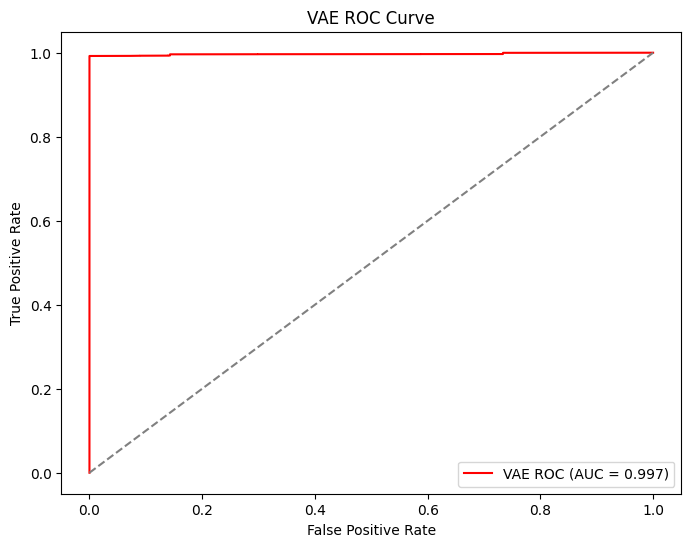

In [ ]:
import matplotlib.pyplot as plt

# ... after computing the ROC curve:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"VAE ROC (AUC = {roc_auc:.3f})", color="red")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("VAE ROC Curve")
plt.legend()
plt.savefig('vae_roc.png', dpi=300)
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix,f1_score,  classification_report, roc_curve, auc

y_true = np.concatenate([np.zeros(len(errors_normal_vae)), np.ones(len(errors_attack_vae))])
y_pred = np.concatenate([
    errors_normal_vae > threshold_vae,
    errors_attack_vae > threshold_vae
]).astype(int)

# Confusion Matrix and Classification Report
cm_vae = confusion_matrix(y_true, y_pred)
print("VAE Confusion Matrix:\n", cm_vae)
print("\nVAE Classification Report:\n", classification_report(y_true, y_pred, target_names=["Normal", "Attack"]))

# F1 Score
f1 = f1_score(y_true, y_pred.round())
print(f"F1 Score: {f1}")

# Compute ROC Curve and AUC for VAE-based detection
# Assume errors_normal_vae and errors_attack_vae are already computed.

# Build the true labels array for VAE errors.
y_true_vae = np.concatenate([np.zeros(len(errors_normal_vae)), np.ones(len(errors_attack_vae))])

# Concatenate the errors.
all_errors_vae = np.concatenate([errors_normal_vae, errors_attack_vae])

# Create a mask to filter out NaN values.
mask = ~np.isnan(all_errors_vae)
filtered_errors_vae = all_errors_vae[mask]
filtered_y_true_vae = y_true_vae[mask]

# Now compute the ROC Curve and AUC with the filtered values.
from sklearn.metrics import roc_curve, auc
fpr_vae, tpr_vae, _ = roc_curve(filtered_y_true_vae, filtered_errors_vae)
roc_auc_vae = auc(fpr_vae, tpr_vae)
print("VAE ROC AUC:", roc_auc_vae)

# Plotting the ROC Curve.
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(fpr_vae, tpr_vae, label=f"VAE ROC (AUC = {roc_auc_vae:.2f})", color="red")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for VAE-based Anomaly Detection")
plt.legend()
plt.show()


# ----- Step 7: Plot ROC Curves for All Models -----
plt.figure(figsize=(8,6))
colors = {
    "Baseline Autoencoder": "blue",
    "Autoencoder": "green",
    "Improved Autoencoder (Ameliore)": "green",
    "MAML Autoencoder": "orange",
    "VAE Density Model": "red"
}
for model_name, eval_data in evaluation_results.items():
    if eval_data["roc_auc"] is not None:
        plt.plot(eval_data["fpr"], eval_data["tpr"],
                 label=f"{model_name} (AUC = {eval_data['roc_auc']:.2f})",
                 color=colors.get(model_name, "black"))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ----- Step 8: Summarize Evaluation Results -----
summary = []
for model_name, eval_data in evaluation_results.items():
    summary.append({
        "Model": model_name,
        "Threshold": eval_data["threshold"],
        "ROC AUC": eval_data["roc_auc"],
        "Confusion Matrix": eval_data["confusion_matrix"],
        "Classification Report": eval_data["classification_report"]
    })
summary_df = pd.DataFrame(summary)
print("Summary of Evaluation Results:")
print(summary_df)
